# Benchmark run analysis

Comparing benchmark runs

In [47]:
import pandas as pd
import numpy as np
from pathlib import Path

In [48]:
RUN_A = 'store/phlag/gaussian/w50k_s1k/repulsion'
RUN_B = 'store/phlag/gaussian/w250k_s1k/repulsion'

run_dir_a = Path(RUN_A)
run_dir_b = Path(RUN_B)

runs_path_a = run_dir_a / "runs.tsv"
runs_path_b = run_dir_b / "runs.tsv"

In [49]:
df_a = pd.read_csv(runs_path_a, sep="\t")
df_b = pd.read_csv(runs_path_b, sep="\t")

In [50]:
PATH_COLUMNS = ["report_path"]
PANEL_COLUMNS = ["in_panel_a", "in_panel_b", "in_panel_relerr", "in_panel_em_divergence", "anomaly_fraction_source"]
ID_COLUMNS = ["run_id", "source_leaf", 'x_variable']

df_a = df_a.drop(columns=PATH_COLUMNS + PANEL_COLUMNS+ID_COLUMNS, errors="ignore")
df_b = df_b.drop(columns=PATH_COLUMNS + PANEL_COLUMNS+ID_COLUMNS, errors="ignore")

In [51]:
df_b.columns

Index(['category', 'subcategory', 'column', 'pattern', 'anomaly_fraction',
       'fraction_bin', 'x_value', 'x_bin', 'branch_length_cu', 'clade_name',
       'clade_number', 'tpr', 'fpr', 'precision', 'f1', 'accuracy', 'roc_auc',
       'tp', 'fp', 'fn', 'tn', 'n_windows', 'label_flipped', 'in_panel_hd_alt',
       'hd_bin', 'mean_relerr_agg', 'covar_relerr_agg', 'em_hd', 'em_gt_hd',
       'transition_null_to_null', 'transition_null_to_alt',
       'transition_alt_to_null', 'transition_alt_to_alt', 'bic',
       'log_likelihood', 'n_trainable_params', 'clip_activation_count',
       'clip_activation_rate', 'clip_unsafe', 'relerr_ABBA_Null_mean',
       'relerr_ABBA_Null_std', 'relerr_ABBA_Alt_mean', 'relerr_ABBA_Alt_std',
       'relerr_BABA_Null_mean', 'relerr_BABA_Null_std', 'relerr_BABA_Alt_mean',
       'relerr_BABA_Alt_std', 'relerr_AABB_Null_mean', 'relerr_AABB_Null_std',
       'relerr_AABB_Alt_mean', 'relerr_AABB_Alt_std', 'exclusion'],
      dtype='object')

In [55]:
total = df_b['n_windows'][0]
alt_a = df_a['fp'] + df_a['tp']
alt_b = df_b['fp'] + df_b['tp']
print(np.mean(alt_a / total), np.mean(alt_b / total))

0.3141356294660361 0.31417438845812234


In [94]:
len(df_a[(df_a['transition_null_to_null']==1.0) | (df_a['transition_alt_to_alt']==1.0)])

112

In [71]:
a = df_a.groupby(['x_bin'])['f1']
b = df_b.groupby(['x_bin'])['f1']
f1_branch_change_mean = (b.mean() - a.mean()) / a.mean()
print('F1 Mean Relative Change Over Branches\n', f1_branch_change_mean)
f1_branch_change_std = (b.std() - a.std()) / a.std()
print('F1 STD Relative Change Over Branches\n', f1_branch_change_std)

F1 Mean Relative Change Over Branches
 x_bin
(0,0.1]   -0.001618
(0.1,1]   -0.001284
(1,5]     -0.000785
high       0.001951
low       -0.005052
Name: f1, dtype: float64
F1 STD Relative Change Over Branches
 x_bin
(0,0.1]   -0.001367
(0.1,1]   -0.005934
(1,5]     -0.003991
high      -0.010200
low        0.001401
Name: f1, dtype: float64


In [67]:
f1_mean_change = (
    df_b.groupby(['category', 'subcategory'])['f1'].mean()
    - df_a.groupby(['category', 'subcategory'])['f1'].mean()
) / df_a.groupby(['category', 'subcategory'])['f1'].mean()
f1_std_change = (
    df_b.groupby(['category', 'subcategory'])['f1'].std()
    - df_a.groupby(['category', 'subcategory'])['f1'].std()
) / df_a.groupby(['category', 'subcategory'])['f1'].std()
print('F1 Relative Mean Change\n', f1_mean_change)
print('F1 Relative STD Change\n', f1_std_change)
# print(df_c.groupby(['category', 'subcategory'])['em_bd'].mean())

F1 Relative Mean Change
 category       subcategory
10X            down           0.001627
               up            -0.003275
admixture      high           0.001951
               low           -0.005052
recombination  down          -0.000214
               up            -0.001658
Name: f1, dtype: float64
F1 Relative STD Change
 category       subcategory
10X            down          -0.004186
               up            -0.004756
admixture      high          -0.010200
               low            0.001401
recombination  down          -0.001912
               up            -0.003400
Name: f1, dtype: float64


In [65]:
print(np.mean(df_a['fp']))
print(np.mean(df_b['fp']))
print(np.mean(df_a['tn']))
print(np.mean(df_b['tn']))
print(np.mean(df_a['fn']))
print(np.mean(df_b['fn']))
print(np.mean(df_a['tp']))
print(np.mean(df_b['tp']))

1289.4925595238096
1288.8511904761904
3897.5074404761904
3894.9821428571427
184.07142857142858
186.36607142857142
579.9285714285714
580.8005952380952


In [58]:
filter = 'x_bin'
target = 'f1'
value1 = "(0,0.1]"
value2 = "(0.1,0.25]"
low_drop = np.mean(df_b[df_b[filter]==value1][target] - df_a[df_a[filter]==value1][target])
high_drop = np.mean(df_b[df_b[filter]==value2][target] - df_a[df_a[filter]==value2][target])
print(low_drop, high_drop)

-0.0005833333333333337 nan


## Mean / std relative error between the two runs

For each report pair sharing a `run_id` in both runs, compare the EM-**Fitted** mean and std per topology (ABBA/BABA/AABB) x state (Null/Alt) from report.tsv lines 20-32: `(fitted_b - fitted_a) / fitted_a`. Average over Null/Alt and topologies per report pair, then average over all report pairs.

In [59]:
import math
import re as _re
from bench.benchmark import TOPOLOGY_NAMES, RELERR_STATES, RELERR_STATISTICS

_RE_FITTED_ROW = _re.compile(
    r'^(\w+)\t(Null|Alt)\t(mean|std)\t([-\d.eE+]+|nan)\t([-\d.eE+]+|nan)\t([-\d.eE+]+|nan)\s*$',
    _re.IGNORECASE,
)

def read_fitted_stats(report_path):
    fitted = {}
    with open(report_path) as handle:
        for line in handle:
            m = _RE_FITTED_ROW.match(line.rstrip("\n"))
            if not m:
                continue
            topology, state, statistic, fitted_str, _gt_str, _relerr_str = m.groups()
            try:
                value = float(fitted_str)
            except ValueError:
                continue
            if math.isnan(value):
                continue
            fitted[(topology, state.capitalize(), statistic.lower())] = value
    return fitted

df_a_raw = pd.read_csv(runs_path_a, sep="\t")
df_b_raw = pd.read_csv(runs_path_b, sep="\t")
paired = df_a_raw[["run_id", "report_path"]].merge(
    df_b_raw[["run_id", "report_path"]], on="run_id", suffixes=("_a", "_b")
)

mean_pair_relerrs, std_pair_relerrs = [], []
for _, row in paired.iterrows():
    fitted_a = read_fitted_stats(row["report_path_a"])
    fitted_b = read_fitted_stats(row["report_path_b"])
    mean_vals, std_vals = [], []
    for topo in TOPOLOGY_NAMES:
        for state in RELERR_STATES:
            for stat, bucket in zip(RELERR_STATISTICS, (mean_vals, std_vals)):
                key = (topo, state, stat)
                if key in fitted_a and key in fitted_b and fitted_a[key] != 0:
                    bucket.append((fitted_b[key] - fitted_a[key]) / fitted_a[key])
    if mean_vals:
        mean_pair_relerrs.append(np.mean(mean_vals))
    if std_vals:
        std_pair_relerrs.append(np.mean(std_vals))

relerr_between_runs = pd.DataFrame([{
    "run_a": RUN_A,
    "run_b": RUN_B,
    "n_report_pairs": len(paired),
    "mean_relerr": np.mean(mean_pair_relerrs),
    "std_relerr": np.mean(std_pair_relerrs),
}])
relerr_between_runs.to_csv("runs.tsv", sep="\t", index=False)
relerr_between_runs

,run_a,run_b,n_report_pairs,mean_relerr,std_relerr
0,store/phlag/gaussian/w50k_s1k/repulsion,store/phlag/gaussian/w250k_s1k/repulsion,672,0.000191,0.000198


## Heatmap comparison: signed change between runs

In [60]:
import re
import matplotlib
import matplotlib.pyplot as plt
from bench.benchmark import DEFAULT_CONCAT_PATTERNS

def hd_bin_rank_grid(df, metric):
    d = df[df['in_panel_hd_alt']]
    order = sorted(d['hd_bin'].unique(), key=lambda s: float(re.split(r'[,\]]', s.strip('[]()'))[0]))
    rank = {label: i for i, label in enumerate(order)}
    d = d.assign(hd_rank=d['hd_bin'].map(rank))
    values = d.groupby(['hd_rank', 'pattern'])[metric].mean().unstack('pattern').reindex(columns=DEFAULT_CONCAT_PATTERNS)
    counts = d.groupby(['hd_rank', 'pattern']).size().unstack('pattern').reindex(columns=DEFAULT_CONCAT_PATTERNS)
    return values, counts, order

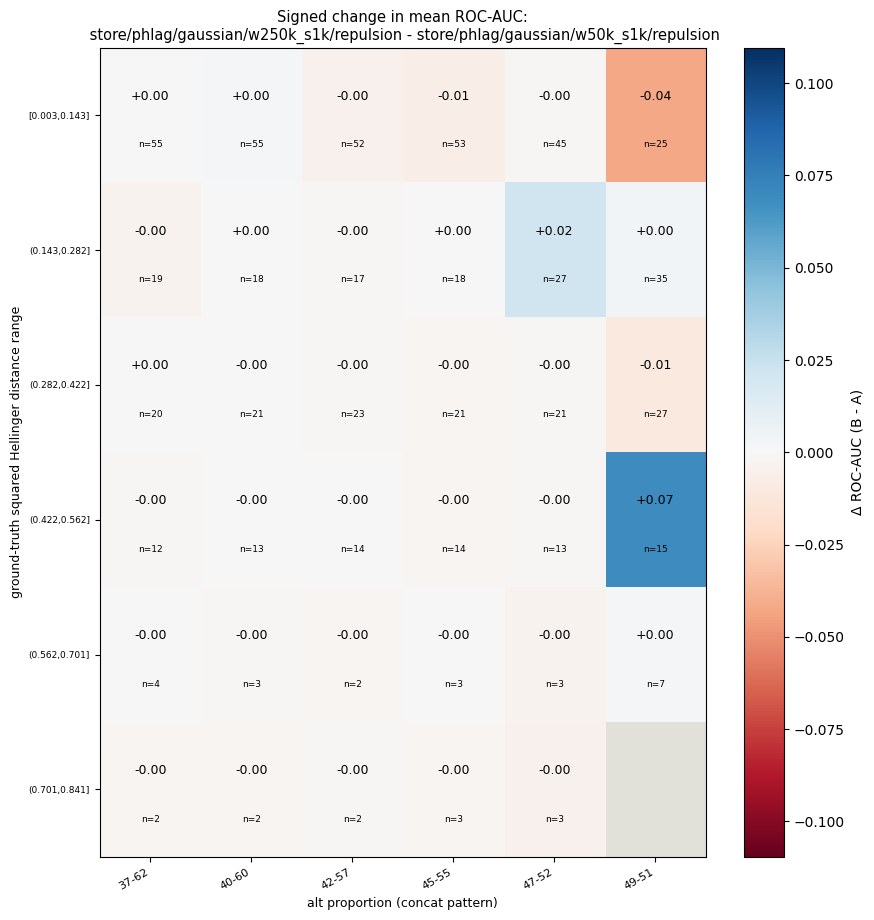

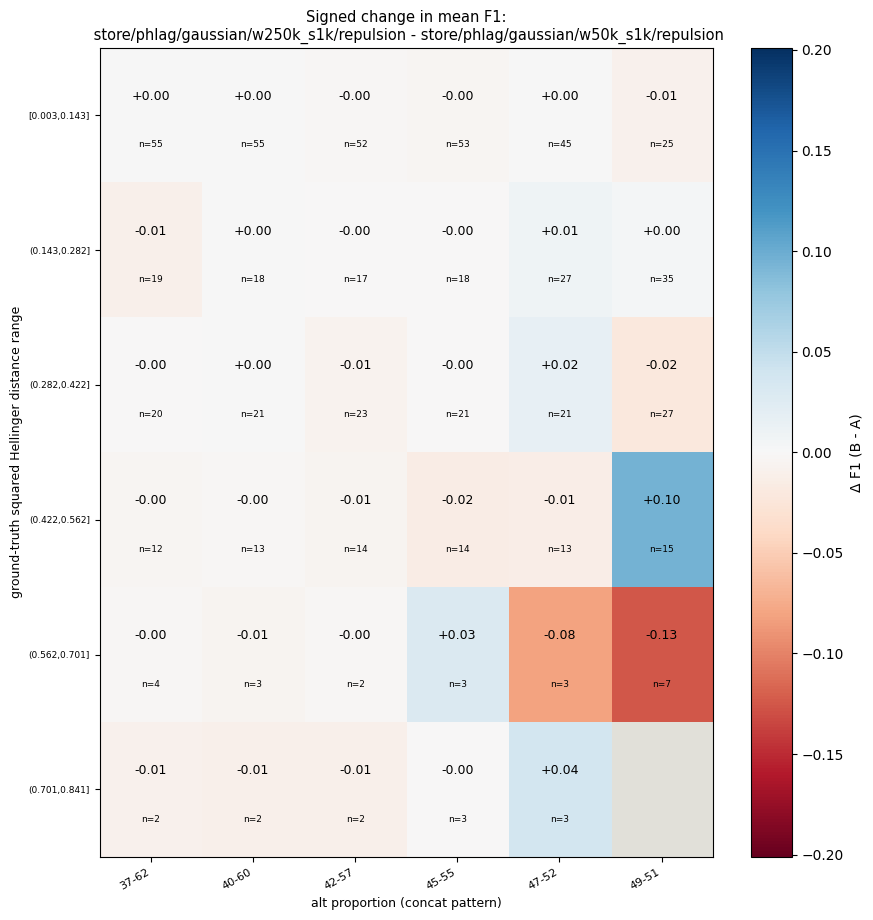

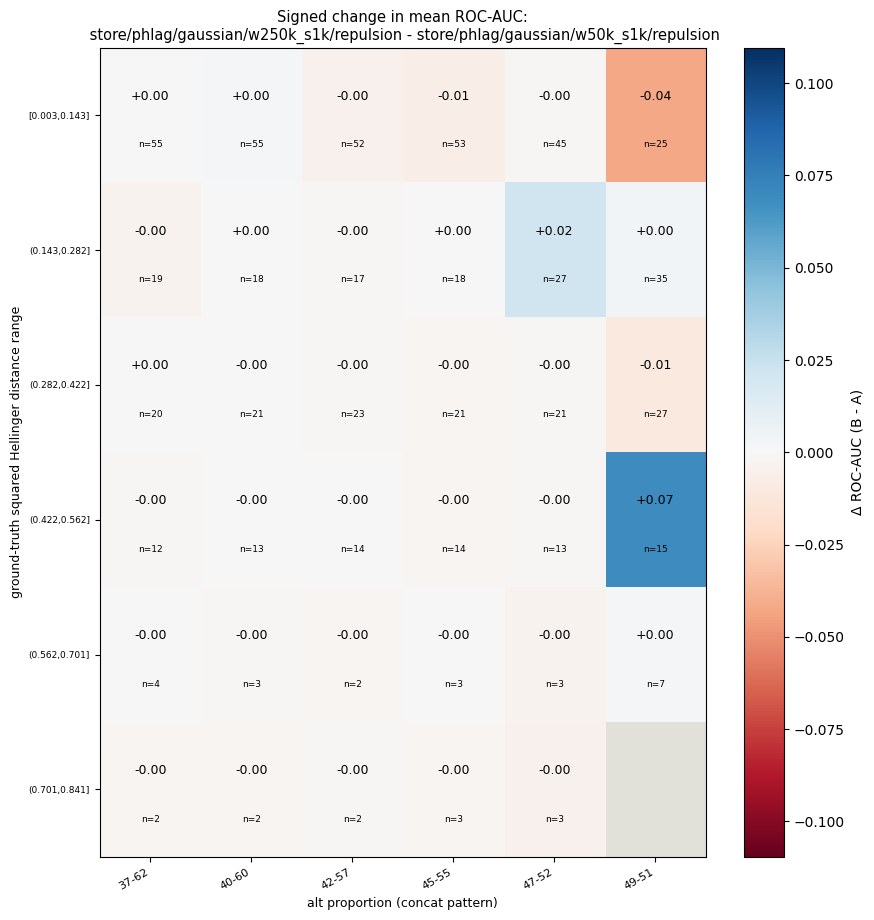

In [61]:
def plot_signed_diff(values_a, counts_a, labels_a, values_b, counts_b, labels_b, metric_label):
    diff = values_b - values_a
    n_a = counts_a.reindex(index=diff.index, columns=diff.columns)
    n_b = counts_b.reindex(index=diff.index, columns=diff.columns)

    vmax = np.nanmax(np.abs(diff.values))
    vmax = (vmax if vmax > 0 else 1.0) * 1.6

    fig, ax = plt.subplots(figsize=(1.15 * len(diff.columns) + 2.0, 1.25 * len(diff.index) + 1.8))
    cmap = matplotlib.colormaps["RdBu"].copy()
    cmap.set_bad(color="#e1e0d9")
    masked = np.ma.masked_invalid(diff.values)
    im = ax.imshow(masked, cmap=cmap, vmin=-vmax, vmax=vmax, aspect="auto")

    for r, rank in enumerate(diff.index):
        for c in range(diff.shape[1]):
            v = diff.values[r, c]
            if np.isnan(v):
                continue
            ax.text(c, r - 0.14, f"{v:+.2f}", ha="center", va="center", fontsize=9)
            na = n_a.values[r, c]
            nb = n_b.values[r, c]
            na = 0 if np.isnan(na) else int(na)
            nb = 0 if np.isnan(nb) else int(nb)
            ax.text(c, r + 0.22, f"n={na}", ha="center", va="center", fontsize=6.5)

    def row_label(rank):
        a = labels_a[rank] if rank < len(labels_a) else "?"
        b = labels_b[rank] if rank < len(labels_b) else "?"
        return f"{a}"

    ax.set_xticks(range(len(diff.columns)))
    ax.set_xticklabels(diff.columns, rotation=30, ha="right", fontsize=8)
    ax.set_yticks(range(len(diff.index)))
    ax.set_yticklabels([row_label(rank) for rank in diff.index], fontsize=6.5)
    ax.set_xlabel("alt proportion (concat pattern)", fontsize=9)
    ax.set_ylabel("ground-truth squared Hellinger distance range", fontsize=9)
    fig.colorbar(im, ax=ax, label=f"Δ {metric_label} (B - A)")
    ax.set_title(f"Signed change in mean {metric_label}:\n {RUN_B} - {RUN_A}", fontsize=10.5)
    fig.tight_layout()
    return fig

plot_signed_diff(*hd_bin_rank_grid(df_a, 'f1'), *hd_bin_rank_grid(df_b, 'f1'), "F1")
plot_signed_diff(*hd_bin_rank_grid(df_a, 'roc_auc'), *hd_bin_rank_grid(df_b, 'roc_auc'), "ROC-AUC")

## Parameter sweeps: window size / step size vs. metrics

In [88]:
from phlag.caster import format_val

SWEEP_METRICS = ["em_hd", "roc_auc", "f1"]
SWEEP_METRIC_TITLES = {"em_hd": "Fitted Hellinger distance^2", "roc_auc": "ROC-AUC", "f1": "F1"}

def _run_dir_metric_values(run_dir, metrics=SWEEP_METRICS):
    runs_path = run_dir / "runs.tsv"
    if not runs_path.exists():
        print(f"[skip] {runs_path} does not exist")
        return None
    runs_df = pd.read_csv(runs_path, sep="\t")
    return {metric: runs_df[metric].dropna().values for metric in metrics if metric in runs_df.columns}

def _plot_metric_sweep(dirs, x_labels, x_axis_label, suptitle, metrics=SWEEP_METRICS):
    """Box plot per metric, one box per (dir, x_label) pair, each box drawn from that dir's runs.tsv."""
    values_by_dir = {d: _run_dir_metric_values(d, metrics) for d in set(dirs)}
    if all(values is None for values in values_by_dir.values()):
        print(f"{suptitle}: no runs with runs.tsv found for the given dirs")
        return None

    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 4))
    if len(metrics) == 1:
        axes = [axes]
    for ax, metric in zip(axes, metrics):
        box_labels, box_data = [], []
        for d, label in zip(dirs, x_labels):
            values = values_by_dir[d]
            if values is None or metric not in values or len(values[metric]) == 0:
                if values is not None:
                    print(f"[skip] no {metric!r} values for {d}")
                continue
            box_labels.append(label)
            box_data.append(values[metric])
        ax.boxplot(box_data, tick_labels=box_labels)
        ax.set_xlabel(x_axis_label)
        ax.set_ylabel(metric)
        ax.set_title(SWEEP_METRIC_TITLES[metric])
        ax.tick_params(axis="x", rotation=30)
        ax.yaxis.grid(True, linestyle="--", alpha=0.4)
        ax.set_axisbelow(True)

    fig.suptitle(suptitle)
    fig.tight_layout()
    return fig

def plot_dir_sweep(dirs, prefix="", suffix=""):
    """Box plot of SWEEP_METRICS across an arbitrary list of run subdirectories, e.g.
    plot_dir_sweep(["repulsion", "annealing", "var2x/repulsion", "var2x/repulsion/annealing"],
                    prefix="store/phlag/gaussian/w50k_s1k")
    or, for a window/step size sweep:
    plot_dir_sweep(["w50k_s1k", "w100k_s1k"], prefix="store/phlag/gaussian")
    or, with a common suffix across variants:
    plot_dir_sweep(["", "repulsion"], prefix="store/phlag/gaussian/w50k_s1k/var2x", suffix="gd")
    Each dir is resolved as prefix/dir/suffix and must contain its own runs.tsv."""
    full_dirs = [Path(prefix) / d / suffix for d in dirs]
    suptitle = f"Dir sweep: {prefix}/[...]/{suffix}" if suffix else f"Dir sweep: {prefix}/[...]"
    return _plot_metric_sweep(full_dirs, dirs, "run", suptitle)

Demo: currently only `store/phlag/gaussian/w50k_s1k` exists, so the window/step sweep below produces a single box per subplot. Add more `w{window}_s{step}` dirs as they're created with `bench/benchmark.py --create`.

`plot_dir_sweep` takes any list of run subdirectories sharing a common `prefix`/`suffix` — window/step size sweeps are just one instance (dir names formatted as `w{format_val(window)}_s{format_val(step)}`), alongside e.g. comparing optimizer variants.

[skip] store/phlag/gaussian/w50k_s1k/runs.tsv does not exist
Dir sweep: store/phlag/gaussian/[...]: no runs with runs.tsv found for the given dirs
[skip] store/phlag/gaussian/w50k_s1k/annealing/runs.tsv does not exist


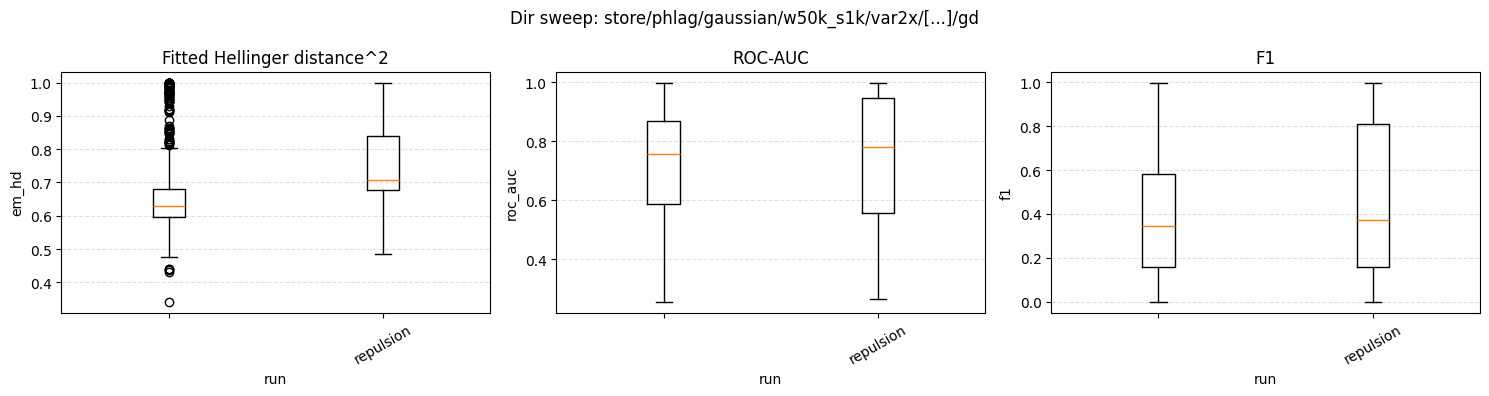

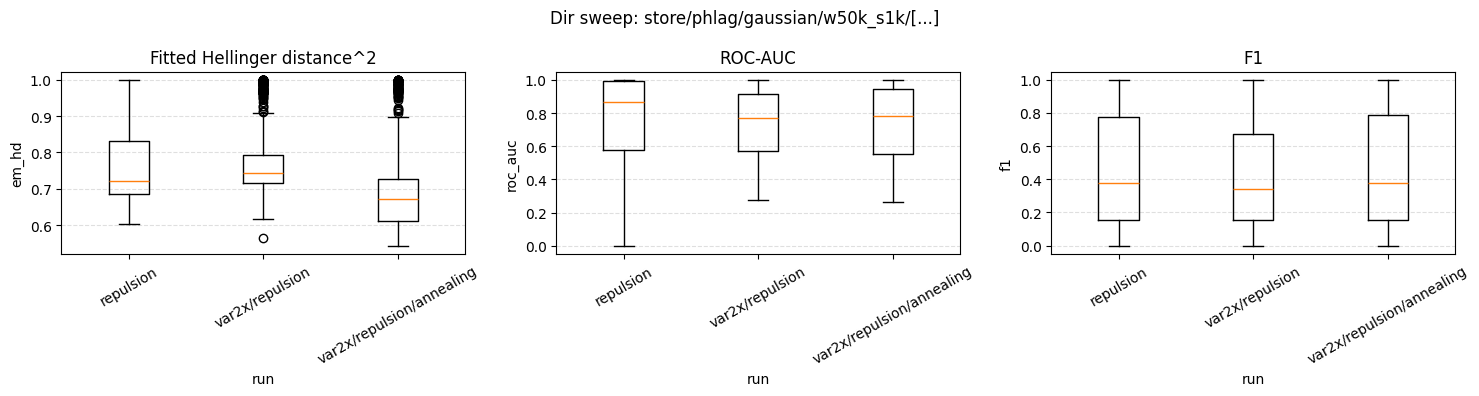

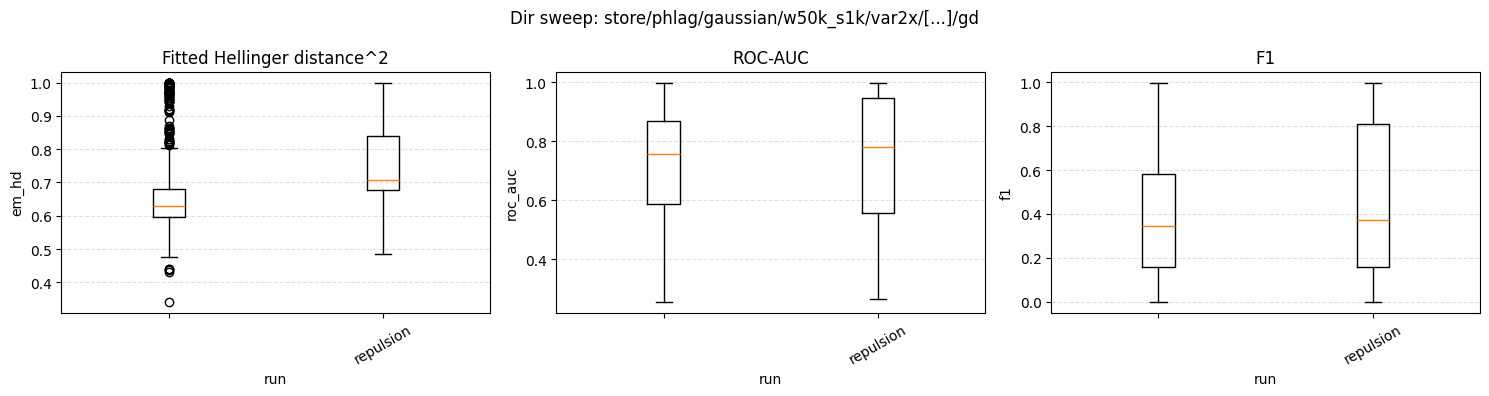

In [89]:
plot_dir_sweep(["w50k_s1k"], prefix="store/phlag/gaussian")

plot_dir_sweep(
    ["repulsion", "annealing", "var2x/repulsion", "var2x/repulsion/annealing"],
    prefix="store/phlag/gaussian/w50k_s1k",
)

plot_dir_sweep(
    ["", "repulsion"], prefix="store/phlag/gaussian/w50k_s1k/var2x", suffix="gd",
)

In [ ]:
plot_dir_sweep(
    ["repulsion", "repulsion/annealing", "var2x/repulsion", "var2x/repulsion/annealing"],
    prefix="store/phlag/gaussian/w50k_s1k",
)